# Imports and Functions

In [ ]:
# imports
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import time
import os

In [ ]:
# We use this function for plotting later.
def plot_linear_regression(x_data,y_data,ws,bs,losses,plot_line_every=20):
    fig, [ax1,ax2,ax3] = plt.subplots(1,3,figsize=(15, 4))
    ax1.scatter(x_data,y_data,c='r',s=5)
    ax1.set_xlabel("x")
    ax1.set_ylabel('y')
    ax2.set_xlabel('w')
    ax2.set_ylabel("b")
    ax3.set_xlabel('step')
    ax3.set_ylabel('loss')

    ax1.scatter(x_data,y_data,c='r',s=5, label='data')
    ax1.set_xlabel("x")
    ax1.set_ylabel('y')

    min_x, max_x = min(x_data), max(x_data)

    if ws is not None and bs is not None:
        for step in np.arange(0,len(ws),plot_line_every):
            w, b = ws[step], bs[step]
            ax1.plot(np.linspace(min_x,max_x,10), w*np.linspace(min_x,max_x,10)+b, label=step)
        ax1.legend(title="epoch")
        ax2.scatter(ws, bs, s=3, c = np.arange(len(ws)), cmap='viridis')
        ax2.grid(True)
    ax3.plot(losses)

# PyTorch Tensors
PyTorch is an open-source machine learning library developed by Facebook's AI Research lab. It provides a flexible and dynamic computational graph system that allows for easy experimentation with neural networks and deep learning models. PyTorch is known for its simplicity, ease of use, and flexibility, making it a popular choice among researchers and developers in the field of artificial intelligence. It also offers support for GPU acceleration, distributed computing, and a rich ecosystem of tools and libraries for building and training machine learning models.


PyTorch tensors are the fundamental data structure used for building and training neural networks within the PyTorch framework. Similar to arrays or matrices, tensors are multi-dimensional arrays that can represent scalar values, vectors, matrices, or even higher-dimensional data. Tensors in PyTorch are highly efficient for numerical computations and are designed to work seamlessly with GPU acceleration, enabling faster training of deep learning models. They also support automatic differentiation, a key feature for implementing various optimization algorithms in neural network training. PyTorch tensors offer a wide range of operations for manipulating and transforming data, making them essential for building sophisticated machine learning models.

We can only scratch the surface of tensors here. You can learn more from the PyTorch documentation.

**Contents**
- Tensor instantiation
- Operations, matrix-vector multiplication, broadcasting
- GPU vs CPU

In [ ]:
# A torch tensor is a multi-dimensional matrix containing elements of a single data type.
x = torch.tensor([1.0,2.0])
y = torch.tensor([3.0,2.0])
A = torch.tensor([[3.0,4.0],
                  [0.0,1.0]])

In [ ]:
# Tensors have a lot of built-in functionality.
print(f"Mean of x: {x.mean()}")
print(f"Cholesky decomposition of A:\n{torch.linalg.cholesky(A)}")

Mean of x: 1.5
Cholesky decomposition of A:
tensor([[1.7321, 0.0000],
        [0.0000, 1.0000]])


In [ ]:
# Torch implements mathematical and logical operations over tensors. These operations are done elementwise.
print(f"x + y: {x + y}")
print(f"x * y: {x * y}")
print(f"x == y: {x == y}")

x + y: tensor([4., 4.])
x * y: tensor([3., 4.])
x == y: tensor([False,  True])


In [ ]:
# Careful, when tensors are not of the same dimension, they may be broadcasted (repeated along a dimension, as in numpy).
# Be aware of that, since this can lead to your code running but not doing what you want.
print(f"A + x:\n{A + x}\n-> Elementwise addition of every row of A with x.")
print(f"A * x:\n{A * x}\n-> Elementwise multiplication of every row of A with x.")
# For matrix vector multiplication, we can use torch.matmul.
print(f"torch.matmul(A,x): {torch.matmul(A,x)} -> Matrix vector product of A and x.")
# Matmul can behave differently for different dimensions of its arguments.
print(f"torch.matmul(y,x): {torch.matmul(x,y)} -> Dot product product of x and y.")

A + x:
tensor([[4., 6.],
        [1., 3.]])
-> Elementwise addition of every row of A with x.
A * x:
tensor([[3., 8.],
        [0., 2.]])
-> Elementwise multiplication of every row of A with x.
torch.matmul(A,x): tensor([11.,  2.]) -> Matrix vector product of A and x.
torch.matmul(y,x): 7.0 -> Dot product product of x and y.


In [ ]:
## Main
# So far we could've used numpy. Torch implements a CPU and a GPU version of tensors.
y_gpu = torch.tensor([3,4], device='cuda' if torch.cuda.is_available() else 'cpu')
x = x.to('cuda' if torch.cuda.is_available() else 'cpu')
# To use any tensor operations, all tensors need to be on the same device.
# You can send tensors to another device, using the .to("[cpu|cuda]") command.
# (Make sure that you have selected a GPU runtime in Colab.)
res = x + y_gpu
print(res)

tensor([4., 6.], device='cuda:0')


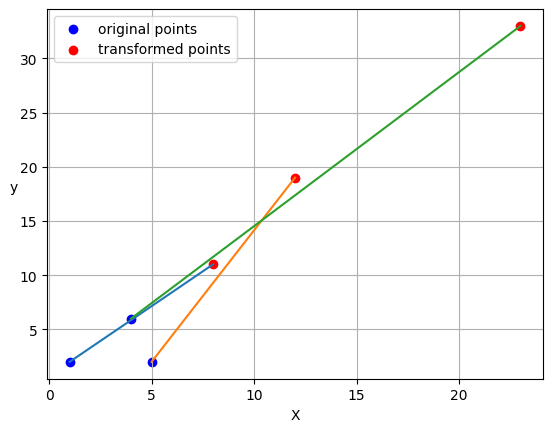

In [ ]:
x1 = torch.tensor([1.0, 2.0])
x2 = torch.tensor([5.0, 2.0])
x3 = torch.tensor([4.0, 6.0])
X = torch.stack([x1, x2, x3], dim=0)
A = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0]])
b = torch.tensor([1.0])
y = X @ A + b

plt.scatter(X[:,0], X[:,1], c='blue', label='original points')
plt.scatter(y[:, 0], y[:, 1], c='red', label='transformed points')
for i in range(len(X)):
    plt.plot([X[i,0], y[i,0]], [X[i,1], y[i,1]])

plt.xlabel("X")
plt.ylabel("y", rotation=0)
plt.grid()
plt.legend()
plt.show()

**Tasks**:
1. Solve the GPU issue in the last cell.
2. Write and plot a simple 2D linear function y = A*x+b for multiple values of x with one line (no loops) using PyTorch. The vectors x are here stacked to a matrix X.

**Solution:**

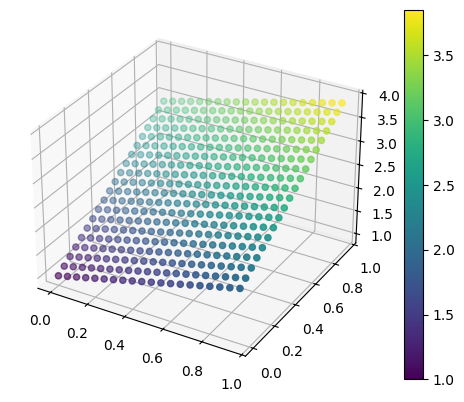

In [ ]:
## Main
# Task 2.
X = torch.tensor([[x,y] for x in range(20) for y in range(20)])/20.
A = torch.tensor([1.,2.])
b = torch.tensor(1.)

y = X @ A + b # Your code here (hint: you can do this using broadcasting or matrix-matrix multiplication; Transposing a matrix is done with A.T).

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
s = ax.scatter(X[:,0], X[:,1], y, c=y, cmap='viridis')
fig.colorbar(s)

# Autograd
Autograd is a key feature of PyTorch that automatically computes gradients for tensors. It enables automatic differentiation, which is essential for training neural networks using techniques like backpropagation. With autograd, PyTorch keeps track of operations performed on tensors and dynamically builds a computational graph to calculate gradients efficiently. This allows users to easily compute gradients without having to manually derive and implement complex mathematical formulas, making it easier to train deep learning models and optimize their parameters effectively.

**Contents:**
- Compute gradients in leaf nodes
- Automatic differentiation graph


In [ ]:
# We can create gradients of our operations with PyTorch's autograd. We can tell PyTorch if we need
# gradients of leaf nodes. Gradients are automatically computed for all operations.
w = torch.tensor([3.],requires_grad=False)
b = torch.tensor([2.],requires_grad=False)
x = torch.tensor([1.],requires_grad=True) # PyTorch will automatically track the gradients w.r.t. x.
y = w * x + b
print(f"y = {y}")

# Using .backward(), we can compute the gradients from a node of the computation graph.
# We can then get the gradient of a tensor. d/dx(3*x+2) = 3
y.backward()
print(f"dy/dx = {x.grad}")

# When saving values, e.g., for plotting, we usually do not want to save the full tensor,
# including the autograd tree. We therefore usually put them on the cpu (.cpu()), detach them from
# the autograd tree (.detach()), and copy them to a numpy array (.numpy()).
print(f"y.cpu().detach().numpy(): {y.cpu().detach().numpy()}")

# For single values we can also use .item().
print(f'y.item(): {y.item()}')

y = tensor([5.], grad_fn=<AddBackward0>)
dy/dx = tensor([3.])
y.cpu().detach().numpy(): [5.]
y.item(): 5.0


**Tasks**:
1. Try to compute dy/dw. You can use w.requires_grad_() as inplace operation to make PyTorch track gradients w.r.t. w. You will have to recompute y to build the graph.
2. Plot d(sin(x))/dx from 0 to 2*pi using autograd (you can use loops).

**Solution**:

In [ ]:
## Main
# Task 1.
#### Your Code here ####
w.requires_grad_()
y = w * x + b
y.backward()
print(f"dy/dw = {w.grad}")

dy/dw = tensor([1.])


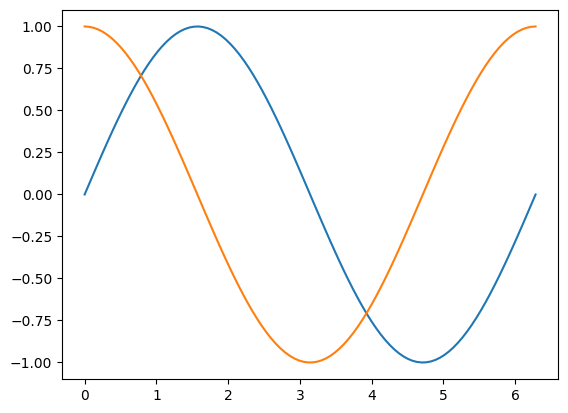

In [ ]:
## Main
# Task 2.
X = torch.linspace(0,2*torch.pi,100, requires_grad=True)
grads = []
#### Your Code here ####
y = torch.sin(X)
y.sum().backward()
grads = X.grad
fig, ax = plt.subplots()
ax.plot(X.cpu().detach().numpy(), y.cpu().detach().numpy())
ax.plot(X.cpu().detach().numpy(), grads.cpu().detach().numpy())
plt.show()

# Linear Regression with Pytorch
Linear regression is a fundamental statistical technique used to model the relationship between a dependent variable and one or more independent variables. The goal of linear regression is to find the best-fitting linear equation that describes the relationship between the variables, allowing us to make predictions based on new input data. The model assumes a linear relationship between the independent variables and the dependent variable, with the coefficients representing the slope and intercept of the line. By minimizing the difference between the actual values and the predicted values (often measured by a loss function like Mean Squared Error), linear regression helps us understand and quantify the relationship between variables, make predictions, and infer insights from data.

We can solve linear regression in closed form but here we will use gradient descent. We first will code this ourselves and then we will use torch's neural network functionality to do so.

**Content:**
- Linear Regression with own code
- Linear Regression with nn.Module

torch.Size([100, 1]) torch.Size([100, 1])


Text(0, 0.5, 'y')

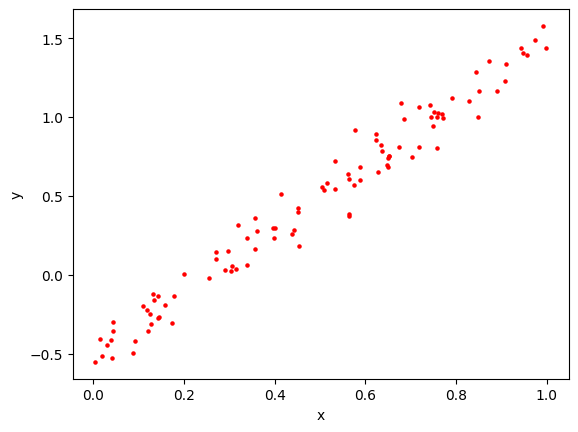

In [ ]:
# We use a very simple dataset of linear data corrupted by noise.
x_data = torch.rand((100,1), requires_grad=False)
y_data = 2 * x_data + -0.5 + 0.1 * torch.randn_like(x_data)
print(x_data.shape, y_data.shape)

# Plot the data.
fig, ax = plt.subplots()
ax.scatter(x_data,y_data,c='r',s=5)
ax.set_xlabel("x")
ax.set_ylabel('y')

0.08589911460876465 0.5257061123847961


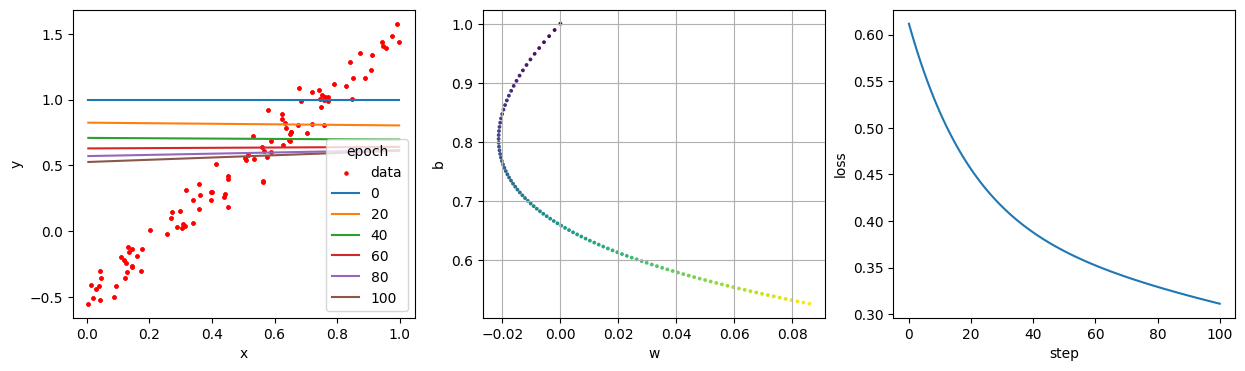

In [ ]:
## Main
# We will learn the two parameters w and b. We need gradients for them.
w = torch.tensor(0., requires_grad=True)
b = torch.tensor(1., requires_grad=True)

# We will plot those variables and the loss over time.
ws = []
bs = []
losses = []

# Hyperparameters.
lr = 0.01
epochs = 101

# Optimization loop.
for step in range(epochs):
    # The forward pass of the network.
    y_predicted = w*x_data+b
    # We use MSE as our loss function.
    loss = torch.square(y_data-y_predicted).mean()
    # loss = torch.sum(torch.absolute(y_data-y_predicted))
    # Compute the gradients.
    loss.backward()
    # Reporting values
    losses.append(loss.item())
    ws.append(w.item())
    bs.append(b.item())
    with torch.no_grad():
        # Apply a step of gradient descent.
        w -= w.grad * lr
        b -= b.grad * lr
        # We here reset the gradients for the next step of gradient descent.
        w.grad.zero_()
        b.grad.zero_()
# This plots the data with the linear function at different steps, the two parameters w and b over epochs, and the loss over epochs.
plot_linear_regression(x_data, y_data, ws, bs, losses)
print(ws[-1], bs[-1])

**Tasks**
1. Play around with different learning rates and number of iterations. What behavior can you see for high learning rates? Can you set it too high?
2. Try out a different loss function, for example the absolute error. What changes?

**Answer**:
1. setting higher learning rates lets us learn much more quickly and reduce the loss much faster. But, it is worth to consider that the range of numbers here is (0, 1). if, instead, it was (0, 100), for instance, the gradients would be much larger, resulting in oscillating around the minimum point on loss function and possibly not converging to it at all. But in this case, setting higher values of lr would not harm.
2. we would see the mentioned oscillation here, exactly because of the reason mentioned in 1.

## nn.Module

Defining a forward function, computing a loss and gradients using autograd, and updating parameters according to this gradient is used in all of Deep Learning. PyTorch therefore implements functionality so that you do not have to code this all by yourself.

In [ ]:
# We usually use the nn.Module class to define models. We have to implement a forward function that computes the forward pass of our model.
# We here use a linear module of PyTorch (nn.Linear). This can have an arbitrary number of in- and outputs. For one in and one output,
# we have the same model as we have used before.
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        pred = self.linear(x)
        return pred

LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)
w: 1.9934544563293457, b: -0.5049089789390564


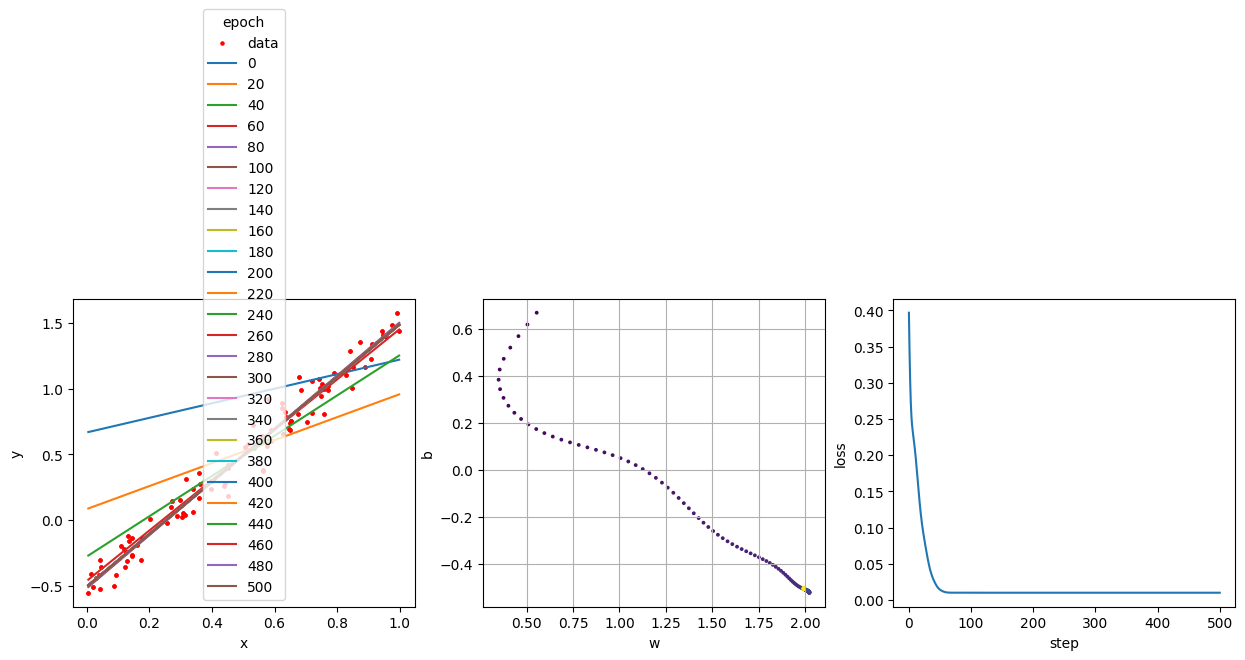

In [ ]:
# Hyperparameters.
lr = 0.05
epochs = 501

# Instantiate our model. This is the same model that we have coded ourselves before.
model = LinearModel()
# We use an optimizer so we do not have to take care of updating the parameters ourselves.
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
# PyTorch implements all kinds of loss functions you may want to use.
mse = torch.nn.MSELoss()
# We can print a model summary, indeed it is the same simple linear model as before.
print(model)

# We will plot some variables and the loss over time.
ws = []
bs = []
losses = []

# Training Loop.
for step in range(epochs):
    # Compute the forward pass.
    y_predicted = model(x_data)
    # Compute the loss.
    loss = mse(y_data, y_predicted)
    # Reset and then compute gradients of the tree.
    optimizer.zero_grad()
    loss.backward()
    # Variables for plotting.
    ws.append(model.linear.weight[0][0].item())
    bs.append(model.linear.bias[0].item())
    losses.append(loss.detach().numpy())
    # Updating the parameters.
    optimizer.step()
# Plot the results.
plot_linear_regression(x_data, y_data, ws, bs, losses)
print(f"w: {ws[-1]}, b: {bs[-1]}")

**Tasks:**
1. Change the data to y = sin(x) + noise on the interval from 0 to 2pi. How does the model perform on this data?
2. Try to add more linear layers to the model. What happens with the loss? Why?

In [ ]:
# task 1
x_data = torch.linspace(0, 2*torch.pi, 100)
x_data = x_data.reshape(100, 1)
y_data = torch.sin(x_data) + torch.randn_like(x_data) * 0.1
# It does not perform well. Since, this model cannot learn this complicated pattern. It just tries to minimize the error as much as possible.

In [ ]:
# task 2
# adding more linear layers would not result in more complexity and higher ability of the model to learn a pattern. No matter how high the number of
# linear layers is, they will work like a single linear layer.

# Neural Networks
Neural networks are computational models composed of interconnected nodes, or neurons, organized into layers. These networks learn and perform various tasks such as classification, regression, and pattern recognition through a process known as training, where the connections between neurons' weights are adjusted to optimize performance. With advancements in deep learning, neural networks with multiple hidden layers, known as deep neural networks, have shown remarkable success across diverse domains such as image and speech recognition, natural language processing, and autonomous driving. Their ability to learn complex patterns from large datasets has made them a cornerstone of modern artificial intelligence research and applications.

**Content:**
- Feed Forward Neural Networks (nn.Linear and Nonlinearities)
- Overfitting and Underfitting
- Train, test, validation split
- Checkpointing (saving and loading models to/from disk)
- Classification: MNIST

In [ ]:
# We first keep on working with a simple 2d dataset that is a sin + noise.
x_data = torch.rand((100,1), requires_grad=False)*2*torch.pi
y_data = torch.sin(x_data) + 0.1 * torch.randn_like(x_data)

In [ ]:
# We split our dataset into train, validation and test set.
idxs = torch.randperm(len(x_data))
train_idxs, val_idxs, test_idxs = idxs[:50], idxs[50:80], idxs[80:]
max_train_idx = int(0.5*len(x_data))
x_train, y_train = x_data[train_idxs], y_data[train_idxs]
x_val, y_val = x_data[val_idxs], y_data[val_idxs]
x_test, y_test = x_data[test_idxs], y_data[test_idxs]

In [ ]:
# We use a simple neural network with one hidden layer and the relu nonlinearity.
class FeedForwardNN(nn.Module):
    def __init__(self, hidden_dim=100) -> None:
        super().__init__()
        self.input = nn.Linear(1, hidden_dim)
        self.hidden1 = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim,1)

    def forward(self, x):
        x = self.input(x)
        x = F.relu(x)
        x = self.hidden1(x)
        x = F.relu(x)
        out = self.output(x)
        return out

Training the neural network...
Training finished. Elapsed time: 34.13 seconds.


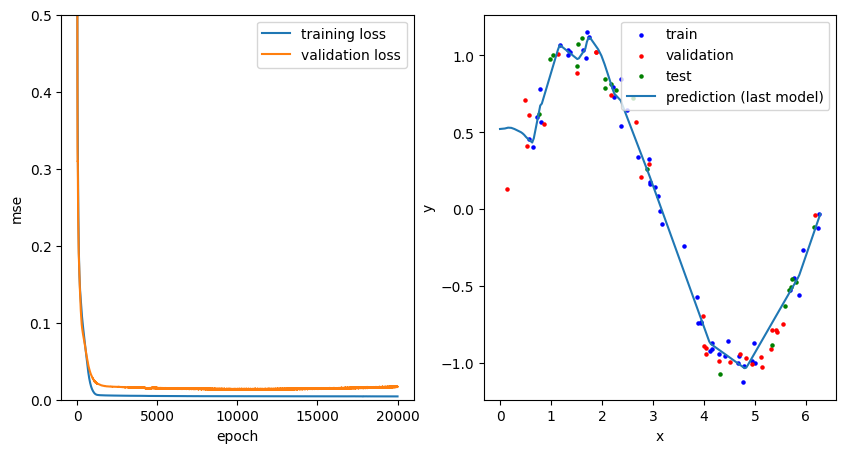

In [ ]:
## Main
# Hyperparameters.
lr = 2e-4
epochs = 20000

# Instantiate our model.
model = FeedForwardNN(100)
# We use an optimizer so we do not have to take care of updating the parameters ourselves.
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#print(model.parameters())
# PyTorch implements all kinds of loss functions you may want to use.
mse = torch.nn.MSELoss()
# We can print a model summary.
# reporting the loss over time
losses_train = []
losses_val = []
best_val_loss = np.inf

# create dir to save the model
save_path = './model_checkpoints/e01/simple_nn/'
os.makedirs(save_path, exist_ok=True)

print('Training the neural network...')
t = time.time()
for epoch in range(epochs):
    # Compute the forward pass.
    y_predicted = model(x_train)
    # Compute the loss.
    loss = mse(y_train, y_predicted)
    # Reset and then compute gradients of the tree.
    optimizer.zero_grad()
    loss.backward()
    # Updating the parameters.
    optimizer.step()
    # Variables for plotting.
    losses_train.append(loss.detach().item())
    with torch.no_grad():
        losses_val.append(mse(model(x_val),y_val).item())
    # If we improve on our validation loss, we checkpoint the model as the new best model.
    if losses_val[-1] < best_val_loss:
        best_val_loss = losses_val[-1]
        torch.save(model,os.path.join(save_path,'best_model.pt'))
# after training is finished we also save our final model
torch.save(model,os.path.join(save_path,'final_model.pt'))
print(f'Training finished. Elapsed time: {time.time()-t:.02f} seconds.')

# plot losses and fit.
fig, [ax1,ax2] = plt.subplots(1,2, figsize=(10,5))
ax1.plot(losses_train, label="training loss")
ax1.plot(losses_val, label="validation loss")
ax1.set_ylabel('mse')
ax1.set_xlabel('epoch')
ax1.set_ylim([0,0.5])
ax1.legend()
ax2.scatter(x_train,y_train,c='b',s=5, label="train")
ax2.scatter(x_val,y_val,c='r',s=5, label='validation')
ax2.scatter(x_test,y_test,c='g',s=5, label='test')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
x_plot = torch.linspace(0.,2*torch.pi,200).unsqueeze(1)
y_plot = model(x_plot)
ax2.plot(x_plot.detach().numpy(), y_plot.detach().numpy(),label='prediction (last model)')
ax2.legend()

In [ ]:
## Main
# We here compare the performance of the model after training and the model with the best
# validation loss on the test set.
best_model = torch.load(os.path.join(save_path,'best_model.pt'), weights_only=False)
test_score_final_model = mse(model(x_test),y_test).item()
test_score_best_model = mse(best_model(x_test),y_test).item()
print(f'Test loss: Final model: {test_score_final_model:.4f}; Best model: {test_score_best_model:.4f}')

Test loss: Final model: 0.0091; Best model: 0.0078


**Tasks:**
1. Explain the difference between train, validation, and test set and why the respective losses are different. Sort them from smallest to largest.
2. As you can see, the validation loss increases, while training loss decreases. Why? Can you increase this effect?
3. What is the issue with the way we are doing train-val-test split? Is there a better way (if you have the time, code it)?
4. Training the neural net is relatively slow. Run this model on the GPU. Does this speed up training? Why?
5. Add y = f(x) for the model 'best model' with the lowest validation loss to the plot.

**Answers:**
1. we train the model using train set, validate it during training phase using validation set, and do the final test on the model using test set.
2. what is happening here is called overfitting, meaning that the model is learning the train data too much and also capturing the noise, so it fails on val data. if we incease the number of epochs, this effect also increases.
3. we probably allocate less data than required to training. it could about 70 or 80 percents of the data.
4. yes. running the program on gpu can significantly speed up training, since computations in operations like backpropagation can be done in parallel, which gpu is able to do.
5. Already done.

In [ ]:
# task 1
train_score_best_model = mse(best_model(x_train),y_train).item()
val_score_best_model = mse(best_model(x_val),y_val).item()
test_score_best_model = mse(best_model(x_test),y_test).item()
train_score_final_model = mse(model(x_train),y_train).item()
val_score_final_model = mse(model(x_val),y_val).item()
test_score_final_model = mse(model(x_test),y_test).item()
print(f"final model ->  train_loss: {train_score_final_model:.5f}, val_loss: {val_score_final_model:.5f}, test_loss: {test_score_final_model:.5f}")
print(f"best model ->  train_loss: {train_score_best_model:.5f}, val_loss: {val_score_best_model:.5f}, test_loss: {test_score_best_model:.5f}")

final model ->  train_loss: 0.00431, val_loss: 0.01685, test_loss: 0.00908
best model ->  train_loss: 0.00460, val_loss: 0.01296, test_loss: 0.00778


## Classification: MNIST
Classification in machine learning is a pivotal task where algorithms learn to assign predefined categories or labels to input data based on its features. It's a fundamental aspect of supervised learning, crucial for tasks like spam detection, sentiment analysis, medical diagnosis, and image recognition. Through training on labeled datasets, classification models discern patterns and relationships within the data, enabling them to accurately classify unseen instances. Techniques such as decision trees, support vector machines, and neural networks are commonly employed for classification tasks, each with its strengths and applicability depending on the nature of the data and the problem at hand. Effective classification algorithms not only automate decision-making processes but also enhance efficiency and accuracy across various fields by swiftly categorizing vast amounts of information.

MNIST, short for Modified National Institute of Standards and Technology database, is a widely used dataset in the field of machine learning and computer vision. It consists of 70,000 grayscale images of handwritten digits (0 through 9), each image being a 28x28 pixel grid. MNIST serves as a benchmark for evaluating algorithms in tasks such as digit recognition and classification. Its simplicity and availability have made it a standard dataset for researchers and practitioners to test and compare different machine learning models, particularly neural networks. MNIST has played a pivotal role in advancing the field of deep learning and remains an essential resource for developing and benchmarking image classification algorithms.

In [ ]:
# Download and construct MNIST dataset.
train_dataset = torchvision.datasets.CIFAR10(root='./data/',
                                          train=True,
                                          transform=torchvision.transforms.ToTensor(),
                                          download=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data/',
                                          train=False,
                                          transform=torchvision.transforms.ToTensor(),
                                          download=True)
# Dataset size:
print(f"Samples in train set: {len(train_dataset)}")
print(f"Samples in test set: {len(test_dataset)}")

# input/output size
image, label = train_dataset[0]
input_size = np.prod(image.size())
output_size = len(train_dataset.classes)

100%|██████████| 170M/170M [00:16<00:00, 10.4MB/s]


Samples in train set: 50000
Samples in test set: 10000


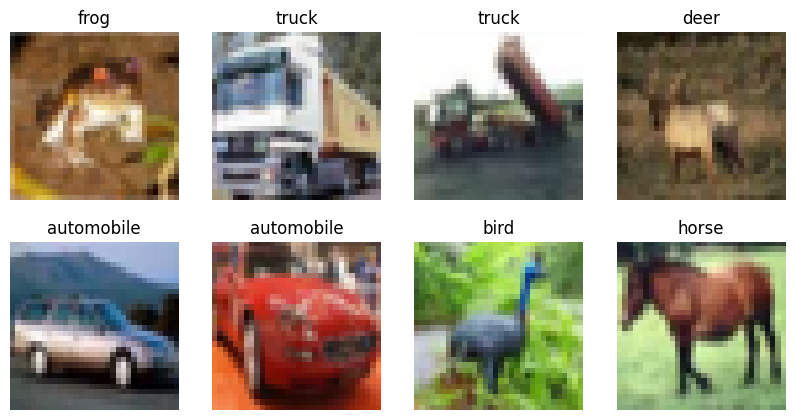

In [ ]:
# Plot some of the images.
fig, axs = plt.subplots(2,4,figsize=(10,5))
for i, ax in enumerate(axs.flatten()):
    image, label = train_dataset[i]
    ax.imshow(np.einsum('ijk->jki',image),
              cmap='Greys' if image.shape[0] == 1 else None)
    ax.set_title(train_dataset.classes[label])
    ax.axis('off')


In [ ]:
# Data loader (this provides queues and threads in a very simple way).
batch_size = 256
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True,
                                           num_workers=0,
                                           pin_memory=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=True,
                                          num_workers=0,
                                          pin_memory=True)


In [ ]:
## Main
# A simple feed-forward neural network for classification.
class FeedForwardModel(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.input = nn.Linear(input_size, 60)
        self.hidden_1 = nn.Linear(60, 20)
        self.hidden_2 = nn.Linear(20, 10)
        self.output = nn.Linear(10, output_size)

    def forward(self, x):
        x = self.input(x)
        x = F.mish(x)
        x = self.hidden_1(x)
        x = F.mish(x)
        x = self.hidden_2(x)
        x = F.mish(x)
        x = self.output(x)
        return x

In [ ]:
# Parameters
device = 'cuda'
lr = 3e-4
epochs = 20

# Instatiate model, loss, and optim.
model = FeedForwardModel(input_size,output_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
cat_cross = torch.nn.CrossEntropyLoss()

# For reporting the accuracy over epochs. Accuracy measures the percentage of classifications
# that are done correctly by the model. This is a typical metric to report for classification
# tasks. Note that the loss function is the categorical cross-entropy, not the accuracy.
accuracy_train = np.zeros(epochs)
accuracy_test = np.zeros(epochs)
def accuracy(y_true, y_pred):
    return ((y_pred.detach()==y_true.detach()).sum()/len(y_pred)*100.).item()


# Training loop.
t = time.time()
for epoch in range(epochs):
    for X,y in train_loader:
        X,y = X.to(device), y.to(device)
        y_pred = model(X.flatten(1))
        loss = cat_cross(y_pred,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        accuracy_train[epoch]+=accuracy(y,y_pred.argmax(dim=1))
    # Report accuracy (note that train accuracy is recorded during the epoch, test is recoreded after an epoch).
    accuracy_train[epoch] /= np.ceil(len(train_dataset)/batch_size)
    with torch.no_grad():
          for X_test, y_test in test_loader:
                X_test,y_test = X_test.to(device), y_test.to(device)
                accuracy_test[epoch]+=accuracy(y_test,model(X_test.flatten(1)).argmax(dim=1))
    accuracy_test[epoch] /= np.ceil(len(test_dataset)/batch_size)
    print(f"Epoch {epoch} ({time.time()-t:.2f}s) - Loss = {loss.item():.5f}; Acc: train: {accuracy_train[epoch]:.2f}%, test: {accuracy_test[epoch]:.2f}%")
    t = time.time()

Epoch 0 (9.80s) - Loss = 1.86952; Acc: train: 22.87%, test: 29.12%
Epoch 1 (8.54s) - Loss = 1.91931; Acc: train: 31.64%, test: 32.41%
Epoch 2 (9.40s) - Loss = 1.64844; Acc: train: 34.92%, test: 34.60%
Epoch 3 (8.64s) - Loss = 1.59233; Acc: train: 36.91%, test: 37.44%
Epoch 4 (8.67s) - Loss = 1.77205; Acc: train: 38.76%, test: 38.91%
Epoch 5 (7.91s) - Loss = 1.52294; Acc: train: 39.63%, test: 40.65%
Epoch 6 (8.69s) - Loss = 1.51119; Acc: train: 40.62%, test: 41.48%
Epoch 7 (8.75s) - Loss = 1.55783; Acc: train: 41.62%, test: 41.43%
Epoch 8 (7.99s) - Loss = 1.53961; Acc: train: 42.52%, test: 42.53%
Epoch 9 (8.81s) - Loss = 1.69860; Acc: train: 43.33%, test: 42.63%
Epoch 10 (8.75s) - Loss = 1.58362; Acc: train: 43.83%, test: 43.17%
Epoch 11 (8.35s) - Loss = 1.58713; Acc: train: 44.38%, test: 43.68%
Epoch 12 (8.49s) - Loss = 1.50745; Acc: train: 45.04%, test: 43.28%
Epoch 13 (8.81s) - Loss = 1.70692; Acc: train: 45.34%, test: 44.67%
Epoch 14 (8.45s) - Loss = 1.26230; Acc: train: 45.81%, tes

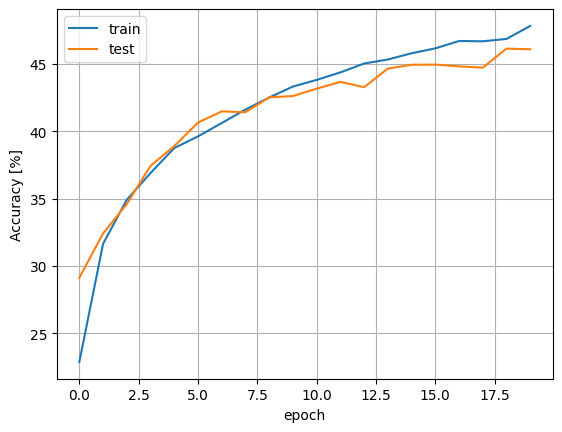

In [ ]:
# plot accuracies over epochs
fig, ax = plt.subplots()
ax.plot(accuracy_train, label='train')
ax.plot(accuracy_test, label='test')
ax.set_xlabel('epoch')
ax.set_ylabel('Accuracy [%]')
ax.grid(True)
ax.legend()

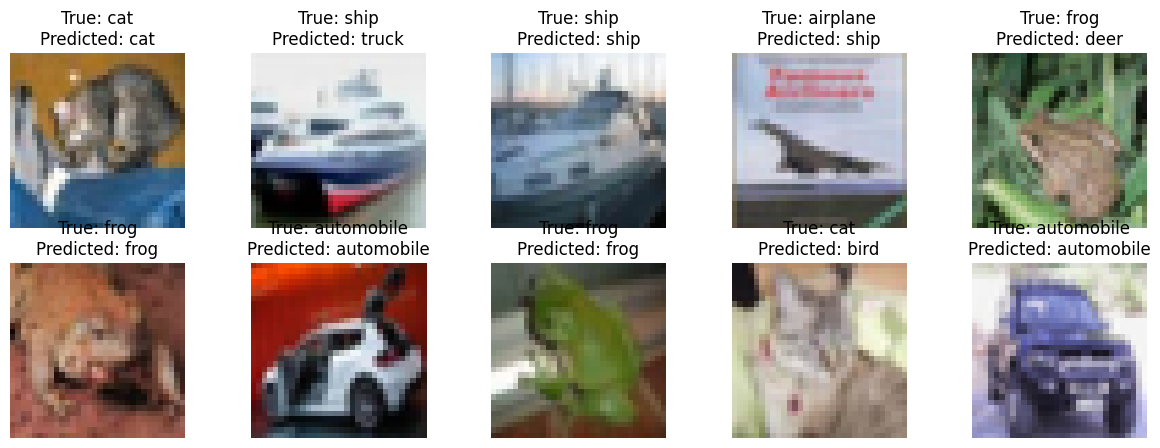

In [ ]:
# Plot some of the images.
fig, axs = plt.subplots(2,5,figsize=(15,5))
for i, ax in enumerate(axs.flatten()):
    image, label_true = test_dataset[i]
    label_predicted = np.argmax(model(image.to(device).flatten()).cpu().data)
    ax.imshow(np.einsum('ijk->jki',image),
              cmap='Greys' if image.shape[0] == 1 else None)
    ax.set_title(f'True: {train_dataset.classes[label_true]}\nPredicted: {train_dataset.classes[label_predicted]}')
    ax.axis('off')


**Tasks:**
1. Performance is alright but not ideal. Try to get train accuracy up to 99% (Add linear layers/try out different activation functions (e.g., relu, mish, tanh,...)).
2. Try out computing on GPU instead of CPU. Is it always faster?
3. Play around with the CIFAR10 dataset (replace torchvision.datasets.MNIST with torchvision.datasets.CIFAR10). Can you get a high accuracy on this Dataset? Why?

**Answers:**
1. I tried increasing number of epochs and changing activation fuctions. I hit 95% accuracy.
2. Not always. For instance, for small datasets and simpler models, the overhead of transferring data between cpu and gpu can outweight the benefits of using gpu.
3. No. This dataset is much more complicated than MNIST. So, if we want higher accuracy, we will probably need to use CNNs.